<center>


<div style="display: flex; justify-content: center;">
    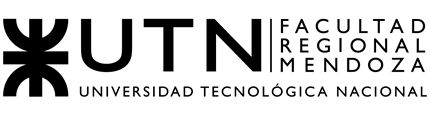
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 9 — SymPy

En todo lo que viste hasta acá, Python manejaba **números**: una variable valía 3, o 2.5, o `3+4j`. Un array de NumPy tiene miles de números. Matplotlib dibuja números. Cuando pedís `np.sin(1.0)`, la computadora calcula un valor aproximado con muchos decimales y te lo devuelve.

Hay otra forma de hacer matemática, una que no pasa por los números: el **álgebra simbólica**. En lugar de preguntar "¿cuánto da $\sin(1.0)$?" trabajás con el símbolo $x$ y manipulás la expresión: la derivás, la factorizás, la resolvés. El resultado es exacto y se expresa con los mismos símbolos, no con un número aproximado.

**SymPy** es la librería estándar de Python para hacer eso. Es lo más cercano a tener Mathematica o Maple integrado en tu notebook. Se usa para:

- Derivar e integrar funciones de manera exacta.
- Resolver ecuaciones con variables literales (no solo con valores concretos).
- Simplificar, factorizar y expandir expresiones algebraicas.
- Tener resultados exactos en fracciones o radicales, sin errores de redondeo.

Los temas de este módulo son:

| Tema | Para qué sirve |
|------|----------------|
| `import sympy as sy` | Cargar la librería |
| `sy.symbols(...)` | Crear variables simbólicas |
| `sy.simplify`, `factor`, `expand` | Manipular expresiones algebraicas |
| `.subs(...)` y `.evalf()` | Sustituir variables y evaluar numéricamente |
| `sy.solve(...)` | Resolver ecuaciones y sistemas |
| `sy.diff(...)` y `sy.integrate(...)` | Derivar e integrar simbólicamente |
| `sy.Piecewise(...)` | Funciones definidas a trozos |
| `sy.lambdify(...)` | Convertir una expresión simbólica en una función numérica para graficar |

> **Numérico vs. simbólico.** NumPy y SymPy son herramientas complementarias, no competidoras. NumPy es rápido y trabaja con números; SymPy es exacto y trabaja con símbolos. Al final de este módulo vas a ver cómo combinarlas: derivar algo con SymPy y después graficarlo con NumPy y Matplotlib.

## 1. Cargar SymPy

Por convención, se importa con el alias `sy`. Además, conviene llamar una vez a `sy.init_printing()`: esto le dice a Jupyter que muestre las expresiones con formato matemático (fracciones apiladas, exponentes en superíndice, etc.) en lugar de texto plano.

In [ ]:
import sympy as sy

sy.init_printing()

`init_printing()` se ejecuta **una sola vez** al abrir el notebook. A partir de ahí, cuando una celda termine con una expresión simbólica, Jupyter la va a dibujar en formato matemático automáticamente.

## 2. Variables simbólicas

El punto de partida de todo trabajo con SymPy es declarar qué letras van a ser símbolos. No alcanza con escribir `x + 2`: antes tenés que decirle a SymPy "la letra `x` es un símbolo". Se hace con la función `sy.symbols`:

In [ ]:
x = sy.symbols("x")
print(type(x))

`x` ya no es un número: es un objeto de la clase `Symbol`. Una vez que existe, podés armar expresiones algebraicas combinándolo con operadores de Python (`+`, `-`, `*`, `/`, `**`) o con funciones de SymPy. El resultado es otra expresión simbólica, que Jupyter muestra en formato matemático.

In [ ]:
x + 2

In [ ]:
x**2 - 2*x - 10

Para funciones matemáticas (seno, coseno, raíz cuadrada, exponencial, logaritmo, etc.) **tenés que usar las versiones de SymPy**, no las de `math` ni las de NumPy. Si usás `math.sin(x)` Python intentaría calcular el seno de un símbolo y daría error; SymPy en cambio sabe representar `sy.sin(x)` como una expresión simbólica.

In [ ]:
sy.sqrt(x) + sy.sin(x) - sy.exp(x)

Se pueden declarar varios símbolos a la vez, separando los nombres por espacios (o por comas):

In [ ]:
p, q, r = sy.symbols("p q r")
p**q + r/q

### 2.1 Restricciones sobre los símbolos

A veces conviene decirle a SymPy algo extra sobre un símbolo: que es **entero**, **real** o **positivo**. Esas restricciones le permiten simplificar mejor. Por ejemplo, si $a$ es positivo, SymPy sabe que $\sqrt{a^2} = a$; sin esa información, deja la expresión sin simplificar.

In [ ]:
n = sy.symbols("n", integer=True)
y = sy.symbols("y", real=True)
a = sy.symbols("a", positive=True)

sy.sqrt(a**2)

Las restricciones más usadas son `integer=True`, `real=True`, `positive=True` y `complex=True`. Si no se especifica nada, SymPy asume que el símbolo es complejo (el caso más general).

## 3. Manipular expresiones

In [ ]:
x, y = sy.symbols("x y")
a, b, c = sy.symbols("a b c")

### 3.1 Simplificación automática

SymPy simplifica automáticamente las cosas más obvias: combina términos semejantes, cancela sumandos opuestos, y ordena la expresión en una forma canónica.

In [ ]:
x**2 + 5*x**3 - 10*x**2 - 5*x - 10*(x + 1)

### 3.2 Factorizar

La función `sy.factor` intenta escribir una expresión como producto de factores:

In [ ]:
expr = a*b + a*c
sy.factor(expr)

In [ ]:
expr = a**2 + 2*a*b + b**2
sy.factor(expr)

In [ ]:
expr = x**2 - 5*x + 6
sy.factor(expr)

### 3.3 Expandir

La operación inversa es `sy.expand`, que distribuye productos y potencias:

In [ ]:
sy.expand((x - 7)*(x - 3))

In [ ]:
sy.expand((x + y)**3)

### 3.4 Simplificar en general

Para casos más complejos (fracciones racionales, identidades trigonométricas, combinaciones de funciones) está la función general `sy.simplify`. Aplica varias técnicas hasta encontrar una forma más corta.

In [ ]:
sy.simplify((x**2 - 3*x) / (x**2 + 3*x))

In [ ]:
sy.simplify(sy.sin(x)**2 + sy.cos(x)**2)

`simplify` es cómodo pero puede ser lento en expresiones grandes. Cuando se sabe qué tipo de manipulación se quiere, conviene usar directamente `factor`, `expand` u otras funciones específicas como `sy.trigsimp` (identidades trigonométricas) o `sy.expand_trig` (sumas de ángulos).

In [ ]:
sy.expand_trig(sy.sin(x + y))

### Actividad 1: factorizar y expandir

1. Definí `x` como símbolo (una sola línea).
2. Factorizá la expresión $x^2 - 7x + 12$ con `sy.factor`.
3. Expandí la expresión $(x + 4)^3$ con `sy.expand`.
4. Tomá el resultado del punto 3 y pasáselo a `sy.factor`. ¿Recuperás la expresión original?

In [ ]:
import sympy as sy
sy.init_printing()

# TU CÓDIGO AQUÍ

## 4. Sustituir y evaluar

Una expresión simbólica no tiene valor numérico hasta que reemplazás sus símbolos por números. Eso se hace con el método `.subs`, que además sirve para reemplazar un símbolo por otra expresión.

### 4.1 Sustitución simbólica

In [ ]:
expr = sy.cos(x)**2 + sy.sin(x)**2
expr.subs(x, y**2)

Importante: `.subs` **no modifica** la expresión original. Devuelve una expresión nueva.

In [ ]:
expr

También se puede sustituir una subexpresión completa, por ejemplo cambiar $\sin(x)$ por $e^x$:

In [ ]:
expr.subs(sy.sin(x), sy.exp(x))

### 4.2 Sustitución numérica

Si el argumento de `.subs` es un número, la expresión se evalúa en ese punto:

In [ ]:
expr2 = x**2 + 3*x + 1
expr2.subs(x, 2)

### 4.3 Pasar a decimal con `.evalf()`

Si el resultado contiene fracciones, raíces o constantes como $\pi$, SymPy lo deja en esa forma exacta. Para obtener un decimal hay que encadenar `.evalf()`, que acepta un argumento opcional con la cantidad de dígitos:

In [ ]:
sy.sqrt(2).evalf()

In [ ]:
sy.exp(x).subs(x, 5).evalf(7)

### 4.4 Fracciones exactas: `sy.Rational`

Los literales como `1/2` en Python son `float` (aproximación decimal). Si querés preservar la fracción exacta, usá `sy.Rational(numerador, denominador)`:

In [ ]:
expr = x**2 / 4
expr.subs(x, sy.Rational(3, 2))

El resultado queda como $9/16$ en lugar de $0.5625$. Esto importa en cálculos largos donde los errores de redondeo se van acumulando.

## 5. Resolver ecuaciones

La función `sy.solve` resuelve ecuaciones y sistemas. Trabaja con expresiones **igualadas a cero**: si querés resolver $x - 3 = 0$, pasás `x - 3` directamente.

### 5.1 Ecuación lineal

In [ ]:
x = sy.symbols("x")
sy.solve(x - 3)

El resultado es una **lista** con las soluciones. En este caso, una sola: $x = 3$.

### 5.2 Ecuación cuadrática

In [ ]:
sy.solve(x**2 + 2*x + 2)

Esta cuadrática no tiene raíces reales, así que SymPy devuelve las complejas. Notá que aparece `I` con mayúscula: es la unidad imaginaria según SymPy (no `j` como en Python puro).

### 5.3 Ecuación con varias incógnitas

Cuando la expresión tiene más de un símbolo, hay que indicarle a `solve` respecto a cuál resolver. Por ejemplo, la fórmula general de la cuadrática $ax^2 + bx + c = 0$:

In [ ]:
a, b, c = sy.symbols("a b c")
sy.solve(a*x**2 + b*x + c, x)

El segundo argumento (`x`) le dice a `solve` que queremos las soluciones en función de `a`, `b` y `c`. Obtenemos las dos raíces de la fórmula resolvente.

### 5.4 Sistemas de ecuaciones

Para resolver varias ecuaciones simultáneas, se pasan en una tupla, junto con la tupla de las incógnitas:

$$
\begin{cases}
x + y = 5 \\
x - y = 1
\end{cases}
$$

In [ ]:
y = sy.symbols("y")
sy.solve((x + y - 5, x - y - 1), (x, y))

El resultado es un **diccionario** con los valores que satisfacen las dos ecuaciones.

### Actividad 2: divisor de tensión

Un divisor de tensión resistivo cumple

$$V_{out} = \frac{R_2}{R_1 + R_2} \cdot V_{in}$$

Queremos elegir $R_1$ de manera que, con $V_{in} = 12$ V y $R_2 = 1000$ Ω, la salida sea $V_{out} = 5$ V.

1. Definí `R1, R2, Vin, Vout` como símbolos positivos con `sy.symbols("...", positive=True)`.
2. Armá la expresión `ecuacion = Vout - R2*Vin/(R1 + R2)` (igualada a cero).
3. Sustituí los valores conocidos con `.subs({...})` pasando un diccionario.
4. Resolvé para `R1` con `sy.solve(..., R1)`.

In [ ]:
import sympy as sy
sy.init_printing()

# TU CÓDIGO AQUÍ

## 6. Derivadas

La función `sy.diff` calcula derivadas simbólicas. Toma al menos dos argumentos: la expresión y la variable respecto a la cual derivar.

In [ ]:
x = sy.symbols("x")
expr = sy.exp(x) * sy.cos(x)
sy.diff(expr, x)

### 6.1 Derivadas de orden superior

Un tercer argumento indica el orden de la derivada. Por ejemplo, la derivada segunda de $5x^2 + 3x - 10$:

In [ ]:
sy.diff(5*x**2 + 3*x - 10, x, 2)

### 6.2 Derivadas parciales

Si la expresión tiene varias variables, `diff` deriva respecto a la que le indiques, tratando las otras como constantes:

In [ ]:
y, z = sy.symbols("y z")
f = sy.exp(x*y) + sy.sin(z)
sy.diff(f, y)

### Actividad 3: energía almacenada en un capacitor

La energía almacenada en un capacitor en función de la tensión aplicada es

$$E(v) = \tfrac{1}{2} \, C \, v^2$$

donde $C$ es la capacidad (una constante del componente) y $v$ la tensión.

1. Definí `C` como símbolo positivo y `v` como símbolo real.
2. Armá la expresión `E = sy.Rational(1, 2) * C * v**2` (usando `sy.Rational` para que $1/2$ quede exacto).
3. Calculá $\dfrac{dE}{dv}$ con `sy.diff`. (Deberías obtener $C \cdot v$, que es la carga almacenada $Q$.)
4. Calculá ahora $\dfrac{d^2 E}{dv^2}$. ¿Qué representa físicamente?

In [ ]:
import sympy as sy
sy.init_printing()

# TU CÓDIGO AQUÍ

## 7. Integrales

La función `sy.integrate` calcula integrales simbólicas. Para una **integral indefinida**, se le pasan la expresión y la variable de integración:

In [ ]:
sy.integrate(x**2 + 3*x - 7, x)

SymPy devuelve la primitiva, sin la constante de integración $C$ (asume que el usuario la agrega cuando la necesita).

Para una **integral definida**, la variable se reemplaza por una tupla `(variable, a, b)`:

In [ ]:
sy.integrate(sy.sin(x), (x, 0, sy.pi))

Algunas observaciones:

- `sy.pi` es la constante $\pi$ en versión simbólica (exacta). Distinta de `np.pi`, que es una aproximación en `float`.
- El resultado de la integral definida es **exacto**: $2$ en este caso, sin decimales.
- Si SymPy no encuentra una primitiva en forma cerrada, devuelve la integral sin evaluar.

### Actividad 4: carga acumulada en un capacitor

Un capacitor recibe una corriente que crece linealmente con el tiempo:

$$i(t) = I_0 \cdot t \qquad \text{para } 0 \leq t \leq T$$

La carga acumulada es la integral de la corriente:

$$Q = \int_0^{T} i(t)\, dt$$

1. Definí `t` como símbolo real, `I0` como positivo y `T` como positivo.
2. Armá la expresión `i = I0 * t`.
3. Calculá `Q = sy.integrate(i, (t, 0, T))`.
4. Sustituí `I0 = 0.1` (ampere por segundo) y `T = 2` (segundos) con `.subs(...)` y luego `.evalf()` para obtener el valor numérico de la carga en coulombs.

In [ ]:
import sympy as sy
sy.init_printing()

# TU CÓDIGO AQUÍ

## 8. Funciones definidas a trozos: `Piecewise`

Algunas funciones cambian de expresión según el intervalo. Por ejemplo:

$$
f(x) = \begin{cases}
x^2 & \text{si } x < 0 \\
\tfrac{1}{10}\,x^3 & \text{si } x \geq 0
\end{cases}
$$

En SymPy se construyen con `sy.Piecewise`, pasando tuplas de la forma `(expresión, condición)`:

In [ ]:
f = sy.Piecewise(
    (x**2, x < 0),
    (sy.Rational(1, 10) * x**3, x >= 0)
)
f

Una vez construida, la función se comporta como cualquier expresión simbólica: se puede sustituir, derivar, integrar.

In [ ]:
f.subs(x, -2)

In [ ]:
f.subs(x, 3)

## 9. Del símbolo al gráfico: `lambdify`

SymPy es ideal para **obtener** una expresión (una derivada, una integral, una solución). Pero para **graficarla** conviene pasarla al mundo numérico: Matplotlib entiende arrays de NumPy, no expresiones de SymPy.

El puente entre los dos mundos es `sy.lambdify`. Toma una expresión simbólica y devuelve una función numérica de Python, lista para evaluarse sobre un array:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = sy.symbols("x")
expr = sy.exp(-x/5) * sy.cos(x)

# Convertir a función numérica
g = sy.lambdify(x, expr, "numpy")

# Evaluar sobre un array y graficar
t = np.linspace(0, 20, 500)
plt.plot(t, g(t))
plt.title("exp(-x/5) · cos(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

Tres detalles:

- El primer argumento de `lambdify` es el símbolo (o la tupla de símbolos) que va a actuar como variable de entrada.
- El segundo es la expresión a convertir.
- El tercero, `"numpy"`, indica que la función resultante debe usar las implementaciones de NumPy (para que acepte arrays y sea rápida).

A partir de ahí, `g` es una función Python común que se puede evaluar en un número o en un array completo.

### Actividad 5: graficar una función y su derivada

Dada la función $f(x) = x^3 - 3x$:

1. Definí `x` como símbolo y armá la expresión `f = x**3 - 3*x`.
2. Calculá la derivada `df` con `sy.diff(f, x)`.
3. Convertí `f` y `df` en funciones numéricas con `sy.lambdify(..., "numpy")`.
4. Creá un array `t = np.linspace(-3, 3, 400)`.
5. Graficá en un mismo gráfico `f(t)` y `df(t)` usando `plt.plot`, con leyendas `"f(x)"` y `"f'(x)"`.
6. Agregá la línea horizontal $y = 0$ con `plt.axhline(0, color="black", linewidth=0.5)` para ver dónde la derivada cambia de signo.

Fijate que donde la derivada cruza el cero, la función $f$ tiene un máximo o un mínimo local.

In [ ]:
import sympy as sy
import numpy as np
import matplotlib.pyplot as plt

sy.init_printing()

# TU CÓDIGO AQUÍ

## Cierre

Con lo que aprendiste en este módulo ya podés:

- Declarar símbolos con `sy.symbols` y construir expresiones.
- Factorizar, expandir y simplificar con `factor`, `expand`, `simplify`.
- Sustituir y evaluar con `.subs` y `.evalf()`.
- Resolver ecuaciones y sistemas con `sy.solve`.
- Derivar e integrar con `sy.diff` y `sy.integrate`.
- Armar funciones por tramos con `sy.Piecewise`.
- Cruzar al mundo numérico con `sy.lambdify` para graficar con Matplotlib.

SymPy es mucho más amplio que lo que cubrimos acá: tiene soporte para álgebra lineal, series, ecuaciones diferenciales, geometría y más. La documentación oficial está en [docs.sympy.org](https://docs.sympy.org/latest/index.html) y es la mejor fuente cuando necesites algo específico.

Con este módulo terminás la introducción a Python del curso. A partir de acá, los **laboratorios** aplican todo lo que viste (variables, control, funciones, objetos, NumPy, Matplotlib y SymPy) a problemas concretos de señales y sistemas.